In [1]:
import pandas as pd 
import numpy as np  

import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

tf.config.set_visible_devices([], 'GPU')

# Load the data.

In [2]:
data = pd.read_hdf("./initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

In [17]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       #(data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 4.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

group_size = 20

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time']).apply(avg)

# Normalize the data. 
# df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index) 
averaged_df = pd.DataFrame(StandardScaler().fit_transform(averaged_df), columns=averaged_df.columns, index=averaged_df.index) 

In [20]:
antigen = list(averaged_df.index.get_level_values('Peptide'))
time = list(averaged_df.index.get_level_values('Time'))

In [21]:
X = np.array(averaged_df.values)
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

# Setup the autoencoder model. 

In [1]:
autoencoder = Sequential([
    layers.Dense(15, activation='elu'),
    layers.Dense(10, activation='softsign'),
    layers.Dense(5, activation='swish'),
    layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
    layers.Dense(5, activation='selu'), 
    layers.Dense(len(ANTIGENS), activation='softmax', name="Output") # Predicting the input. 
])

NameError: name 'tf' is not defined

In [23]:
autoencoder.compile(optimizer='adagrad', loss=losses.CategoricalCrossentropy(), metrics=['categorical_accuracy'])

In [24]:
CHECKPOINT_PATH = "training/train_avg/cp-{epoch:04d}.ckpt"
checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)

BATCH_SIZE = 1024
STEPS_PER_EPOCH = X_train.shape[0] / BATCH_SIZE
SAVE_PERIOD = 10


training_callback = ModelCheckpoint(filepath=CHECKPOINT_PATH,
                                    save_weights_only=True,
                                    verbose=1, 
                                    save_freq=int(SAVE_PERIOD * STEPS_PER_EPOCH)
                                )

# autoencoder.save_weights(CHECKPOINT_PATH.format(epoch=0))

tf.random.set_seed(42)

hist = autoencoder.fit(X_train, y_train,
                epochs=2000,
                shuffle=True,
                validation_data=(X_test, y_test),
                callbacks=[training_callback],
                batch_size=BATCH_SIZE,
                verbose=0)


Epoch 10: saving model to training/train_avg/cp-0010.ckpt

Epoch 20: saving model to training/train_avg/cp-0020.ckpt

Epoch 30: saving model to training/train_avg/cp-0030.ckpt

Epoch 40: saving model to training/train_avg/cp-0040.ckpt

Epoch 50: saving model to training/train_avg/cp-0050.ckpt

Epoch 60: saving model to training/train_avg/cp-0060.ckpt

Epoch 70: saving model to training/train_avg/cp-0070.ckpt

Epoch 80: saving model to training/train_avg/cp-0080.ckpt

Epoch 90: saving model to training/train_avg/cp-0090.ckpt

Epoch 100: saving model to training/train_avg/cp-0100.ckpt

Epoch 110: saving model to training/train_avg/cp-0110.ckpt

Epoch 120: saving model to training/train_avg/cp-0120.ckpt

Epoch 130: saving model to training/train_avg/cp-0130.ckpt

Epoch 140: saving model to training/train_avg/cp-0140.ckpt

Epoch 150: saving model to training/train_avg/cp-0150.ckpt

Epoch 160: saving model to training/train_avg/cp-0160.ckpt

Epoch 170: saving model to training/train_avg/cp


Epoch 1375: saving model to training/train_avg/cp-1375.ckpt

Epoch 1385: saving model to training/train_avg/cp-1385.ckpt

Epoch 1395: saving model to training/train_avg/cp-1395.ckpt

Epoch 1405: saving model to training/train_avg/cp-1405.ckpt

Epoch 1415: saving model to training/train_avg/cp-1415.ckpt

Epoch 1425: saving model to training/train_avg/cp-1425.ckpt

Epoch 1435: saving model to training/train_avg/cp-1435.ckpt

Epoch 1445: saving model to training/train_avg/cp-1445.ckpt

Epoch 1455: saving model to training/train_avg/cp-1455.ckpt

Epoch 1465: saving model to training/train_avg/cp-1465.ckpt

Epoch 1475: saving model to training/train_avg/cp-1475.ckpt

Epoch 1485: saving model to training/train_avg/cp-1485.ckpt

Epoch 1494: saving model to training/train_avg/cp-1494.ckpt

Epoch 1504: saving model to training/train_avg/cp-1504.ckpt

Epoch 1514: saving model to training/train_avg/cp-1514.ckpt

Epoch 1524: saving model to training/train_avg/cp-1524.ckpt

Epoch 1534: saving mode

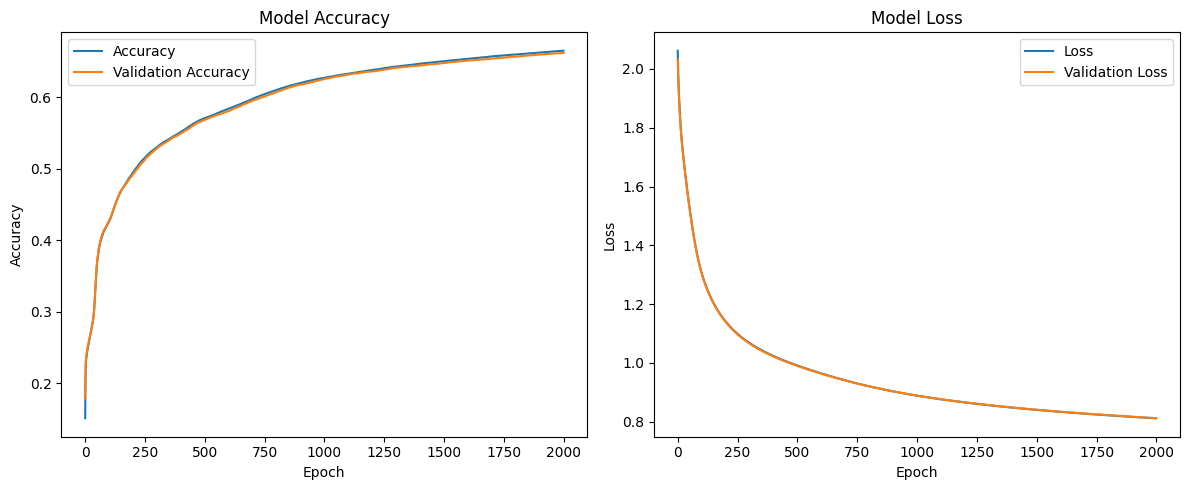

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot the accuracy on the first subplot
ax1.plot(hist.history['categorical_accuracy'], label='Accuracy')
ax1.plot(hist.history['val_categorical_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot the loss on the second subplot
ax2.plot(hist.history['loss'], label='Loss')
ax2.plot(hist.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Get the embedding from the bottleneck layer. 

In [26]:
autoencoder.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 15)                405       
                                                                 
 dense_5 (Dense)             (None, 10)                160       
                                                                 
 dense_6 (Dense)             (None, 5)                 55        
                                                                 
 Bottleneck (Dense)          (None, 2)                 12        
                                                                 
 dense_7 (Dense)             (None, 5)                 15        
                                                                 
 Output (Dense)              (None, 8)                 48        
                                                                 
Total params: 695 (2.71 KB)
Trainable params: 695 (2.7

In [27]:
train_time, test_time = train_test_split(time, test_size=TEST_PROPORTION, random_state=42)
train_antigen, test_antigen = train_test_split(antigen, test_size=TEST_PROPORTION, random_state=42)

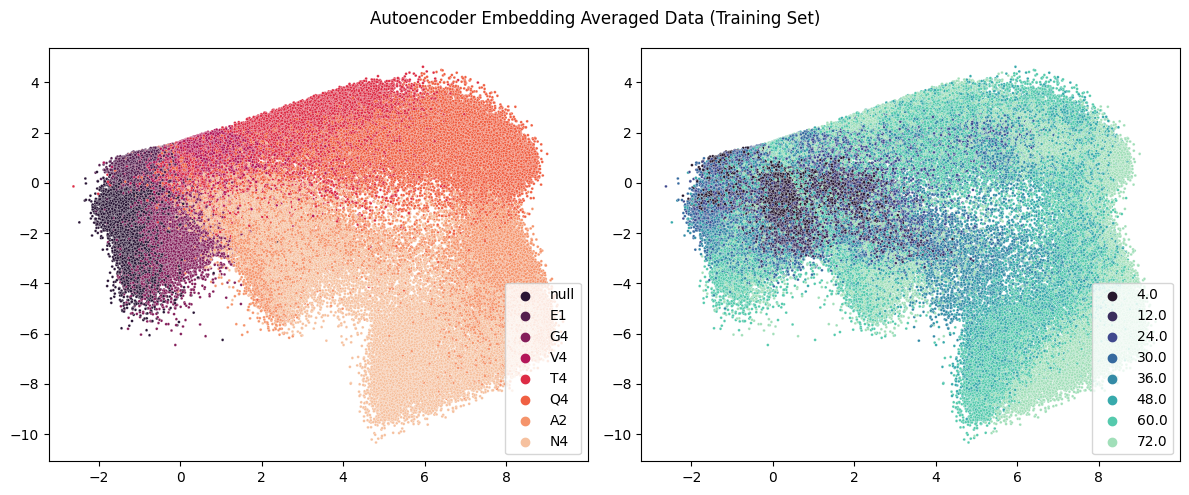

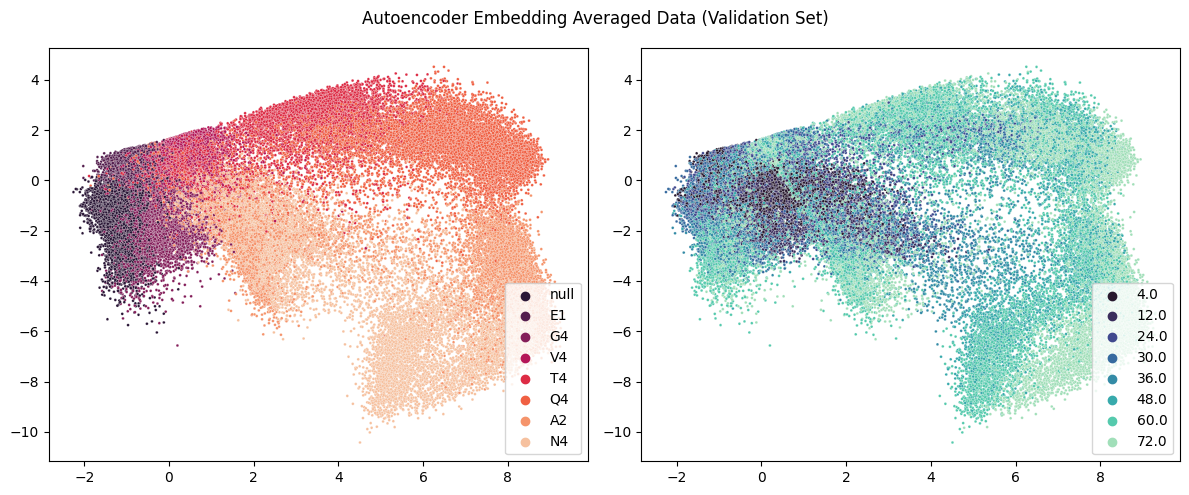

In [33]:
extractor = Model(inputs=autoencoder.inputs,
                        outputs=autoencoder.get_layer("Bottleneck").output)

embedding = np.array( extractor(X_test) )
embedding_train = np.array( extractor(X_train) )
# Create a figure with two subplots


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=embedding_train[:,0], 
    y=embedding_train[:,1], 
    hue=pd.Categorical(train_antigen), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=4, 
    ax=ax1
)

sns.scatterplot(
    x=embedding_train[:,0], 
    y=embedding_train[:,1], 
    hue=pd.Categorical(train_time), 
    palette="mako", 
    s=4, 
    ax=ax2
)

fig.suptitle("Autoencoder Embedding Averaged Data (Training Set)")
ax1.legend(loc="lower right")
ax2.legend(loc="lower right")
plt.tight_layout()



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_antigen), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=4, 
    ax=ax1
)

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_time), 
    palette="mako", 
    s=4, 
    ax=ax2
)

fig.suptitle("Autoencoder Embedding Averaged Data (Validation Set)")
ax1.legend(loc="lower right")
ax2.legend(loc="lower right")
plt.tight_layout()

# Now we can color the scatter plot by different values of markers. 

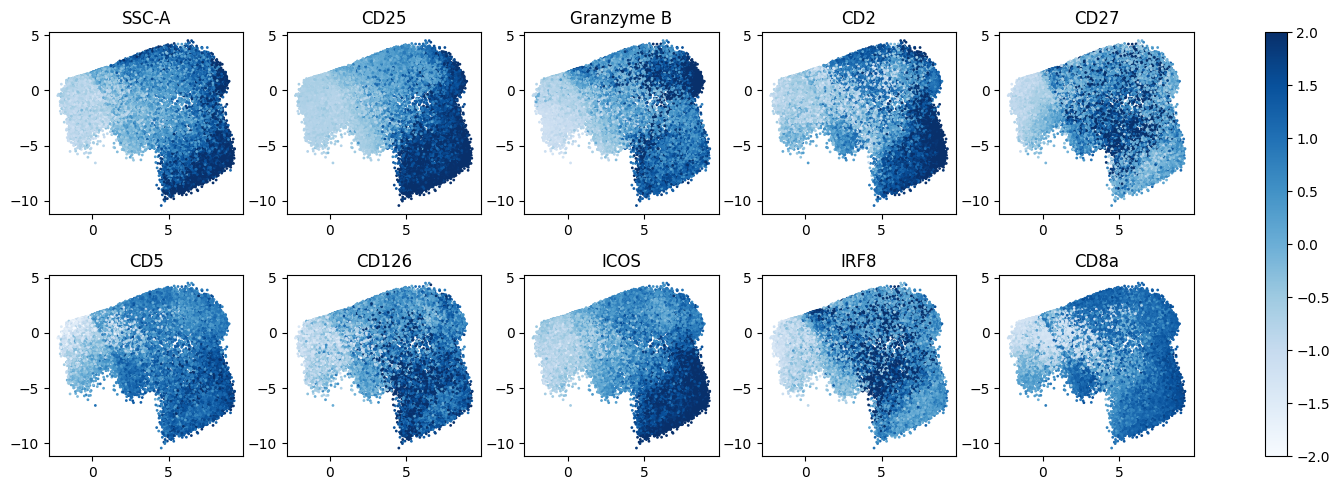

In [29]:
# Plot the top ten markers identified from before. 
MARKERS = ['SSC-A','CD25','Granzyme B','CD2','CD27','CD5','CD126','ICOS','IRF8','CD8a']

fig, axs = plt.subplots(2, 5, figsize=(15,5))

axs = axs.flatten()

vmin = -2 * np.std(averaged_df.values)
vmax = 2 * np.std(averaged_df.values)

for i, marker in enumerate(MARKERS):
    train_marker, test_marker = train_test_split(averaged_df[marker], test_size=TEST_PROPORTION, random_state=42)

    sc = axs[i].scatter(
        x=embedding[:,0], 
        y=embedding[:,1], 
        c=test_marker, 
        cmap='Blues', 
        s=1, 
        vmin=vmin,
        vmax=vmax
    )

    axs[i].set_title(marker)

plt.tight_layout()

# cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
plt.colorbar(sc, ax=axs.ravel().tolist())

# Now we create a confusion matrix. 

In [30]:
from sklearn.metrics import confusion_matrix

y_pred = np.argmax( autoencoder(X_test), axis=1 )
y_true = np.argmax(y_test, axis=1) 

cm = confusion_matrix(y_true, y_pred)

cm

array([[7056,  364, 1364,   11,   20,    2,    6,    0],
       [ 506, 4927,  190,  991,   91,    0,    0,    0],
       [2334,  361, 5099,   85,  142,   23,  201,   14],
       [  89, 1521,  256, 5227, 1392,   26,   27,   75],
       [ 114,  552,  312, 3423, 4960,  889,  162,  218],
       [  45,  594,  205,  860, 1274, 8211,  241,  149],
       [   1,    0,  176,    4,  163,  118, 6744, 3422],
       [   3,    1,  151,    8,  414,   75, 2065, 8229]])

[Text(0, 0.5, 'null'),
 Text(0, 1.5, 'E1'),
 Text(0, 2.5, 'G4'),
 Text(0, 3.5, 'V4'),
 Text(0, 4.5, 'T4'),
 Text(0, 5.5, 'Q4'),
 Text(0, 6.5, 'A2'),
 Text(0, 7.5, 'N4')]

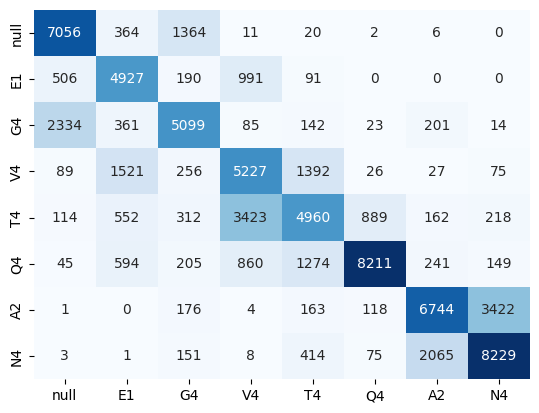

In [31]:
# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

# Set labels for the x and y axes
ax.set_xticklabels(ANTIGENS)
ax.set_yticklabels(ANTIGENS)